# Fig1ab Order data

C:\Users\Administrator.DESKTOP-IME8OVA\AppData\Local\Temp\ipykernel_70240\3195504739.py:127: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  vp = sns.violinplot(


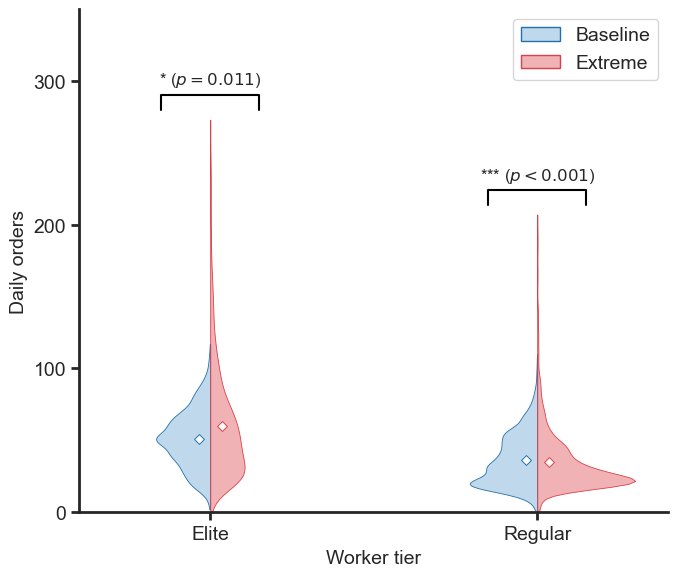

C:\Users\Administrator.DESKTOP-IME8OVA\AppData\Local\Temp\ipykernel_70240\3195504739.py:127: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  vp = sns.violinplot(


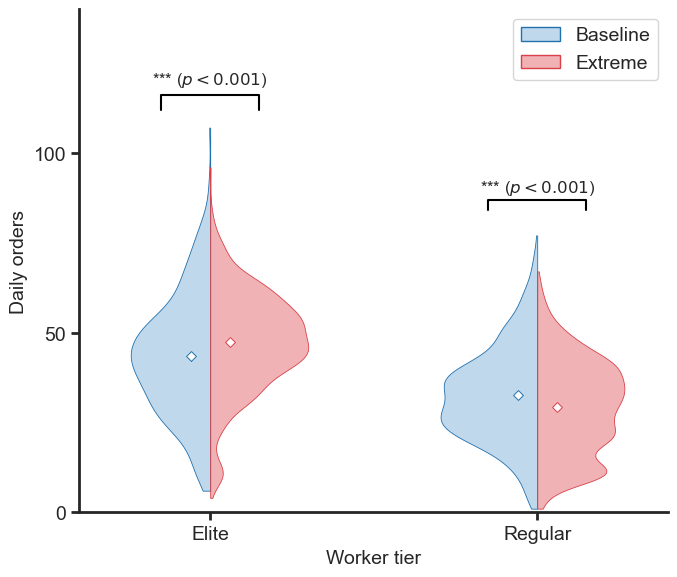

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

# =========================
# Global plot style
# =========================
sns.set_style("ticks")               
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.facecolor': 'white',      
    'figure.facecolor': 'white',
    'axes.linewidth': 2,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,            
})


# =========================
# Color definitions
# =========================
def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16)/255 for i in (0, 2, 4)]
    return (r, g, b, alpha)

COLORS = {
    "base_fill": hex_to_rgba("#BFD8EC", 1.0),   # Baseline fill
    "base_edge": hex_to_rgba("#2171AE", 1.0),   # Baseline edge
    "ext_fill":  hex_to_rgba("#DA4048", 0.4),   # Extreme fill
    "ext_edge":  hex_to_rgba("#DA4048", 1.0),   # Extreme edge
}

# =========================
# Read and preprocess data
# =========================
df = pd.read_csv("PanelResults/worker_day_panel.csv")
df['Ta_max'] = pd.to_numeric(df['Ta_max'], errors='coerce')
df['Ta_min'] = pd.to_numeric(df['Ta_min'], errors='coerce')
df['OrderCount'] = pd.to_numeric(df['OrderCount'], errors='coerce')



# =========================
# Helper functions
# =========================
def bootstrap_ci(data, n_boot=2000, ci=95):
    data = np.asarray(data, dtype=float)
    data = data[~np.isnan(data)]
    if data.size == 0:
        return np.nan, np.nan, np.nan
    means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(means, (100 - ci)/2)
    hi = np.percentile(means, 100 - (100 - ci)/2)
    return np.mean(data), lo, hi

def p_to_star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "n.s."

def prepare_plot_data(baseline_data, extreme_data, cls_name):
    baseline_df = pd.DataFrame({'Orders': baseline_data, 'Class': cls_name, 'Condition': 'Baseline'})
    extreme_df  = pd.DataFrame({'Orders': extreme_data, 'Class': cls_name, 'Condition': 'Extreme'})
    return pd.concat([baseline_df, extreme_df], ignore_index=True)

def add_mean_ci_markers(ax, x_pos, baseline_data, extreme_data, marker_offset=0.035):
    mb, lb, ub = bootstrap_ci(np.asarray(baseline_data, dtype=float))
    me, le, ue = bootstrap_ci(np.asarray(extreme_data, dtype=float))

    def draw_mean_ci_marker(x, lo, hi, mean, edge_color):
        ax.plot([x, x], [lo, hi], color=edge_color, linewidth=0.7, zorder=4)
        ax.scatter(
            [x], [mean], marker='D', s=25,
            facecolor='white', edgecolor=edge_color, linewidth=0.7, zorder=5
        )

    draw_mean_ci_marker(x_pos - marker_offset, lb, ub, mb, COLORS["base_edge"])
    draw_mean_ci_marker(x_pos + marker_offset, le, ue, me, COLORS["ext_edge"])

def add_significance_marker(ax, x_pos, baseline_data, extreme_data, ylim,
                            spine_ratio=0.88, sig_ratio=0.92, sig_h_ratio=0.03):
    baseline_data = np.asarray(baseline_data, dtype=float)
    extreme_data = np.asarray(extreme_data, dtype=float)
    baseline_data = baseline_data[~np.isnan(baseline_data)]
    extreme_data = extreme_data[~np.isnan(extreme_data)]
    if baseline_data.size < 2 or extreme_data.size < 2:
        return

    stat, p = mannwhitneyu(baseline_data, extreme_data, alternative="two-sided")
    star = p_to_star(p)
    p_text = r"$\it{p}<0.001$" if p < 0.001 else rf"$\it{{p}}={p:.3f}$"

    y_sig = ylim[1] * sig_ratio
    h = (ylim[1] - ylim[0]) * sig_h_ratio
    ax.plot([x_pos - 0.15, x_pos - 0.15, x_pos + 0.15, x_pos + 0.15],
            [y_sig, y_sig + h, y_sig + h, y_sig], lw=1.5, color="black")
    ax.text(x_pos, y_sig + h*1.35, f"{star} ({p_text})", ha='center', va='bottom', fontsize=12)

# =========================
# Main plotting function
# =========================
def plot_city(data_dict, city_name, ylim, output_file, show_legend=True,
              spine_ratios=(0.88, 0.88), sig_ratios=(0.92, 0.92),
              sig_h_ratios=(0.03, 0.03), y_tick_interval=None,
              marker_offset=0.035):
    fig, ax = plt.subplots(figsize=(7, 6))

    combined_df = pd.concat([
        prepare_plot_data(data_dict['elite_b'], data_dict['elite_e'], "Elite"),
        prepare_plot_data(data_dict['regular_b'], data_dict['regular_e'], "Regular")
    ])

    vp = sns.violinplot(
        data=combined_df, x="Class", y="Orders", hue="Condition", split=True,
        palette={"Baseline": COLORS["base_fill"][:3], "Extreme": COLORS["ext_fill"][:3]},
        cut=0, inner=None, scale="area", common_norm=True, linewidth=0.6, ax=ax, width=0.6
    )

    # Apply correct face and edge colors
    for i, collection in enumerate(vp.collections):
        if i % 2 == 0:          # Baseline half
            face_rgba = COLORS["base_fill"]
            edge_rgba = COLORS["base_edge"]
        else:                   # Extreme half
            face_rgba = COLORS["ext_fill"]
            edge_rgba = COLORS["ext_edge"]
        collection.set_facecolor(face_rgba)
        collection.set_edgecolor(edge_rgba)
        collection.set_linewidth(0.6)

    add_mean_ci_markers(ax, 0, data_dict['elite_b'], data_dict['elite_e'], marker_offset=marker_offset)
    add_mean_ci_markers(ax, 1, data_dict['regular_b'], data_dict['regular_e'], marker_offset=marker_offset)

    add_significance_marker(ax, 0, data_dict['elite_b'], data_dict['elite_e'],
                            ylim=ylim, spine_ratio=spine_ratios[0],
                            sig_ratio=sig_ratios[0], sig_h_ratio=sig_h_ratios[0])
    add_significance_marker(ax, 1, data_dict['regular_b'], data_dict['regular_e'],
                            ylim=ylim, spine_ratio=spine_ratios[1],
                            sig_ratio=sig_ratios[1], sig_h_ratio=sig_h_ratios[1])

    ax.set_xticks([0, 1])
    ax.set_xlim(-0.4, 1.4)
    ax.set_xticklabels(["Elite", "Regular"])
    ax.set_ylabel("Daily orders")
    ax.set_xlabel("Worker tier")
    ax.set_ylim(ylim)

    if y_tick_interval is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))

    if show_legend:
        legend_elements = [
            Patch(facecolor=COLORS["base_fill"], edgecolor=COLORS["base_edge"][:3], label="Baseline"),
            Patch(facecolor=COLORS["ext_fill"], edgecolor=COLORS["ext_edge"][:3], label="Extreme"),
        ]
        ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=14)
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    fig.tight_layout()
    fig.savefig(output_file, dpi=600)
    plt.show()
    plt.close(fig)

# =========================
# Prepare data
# =========================
sh_data = {
    'elite_b': df[(df['Location']=='Shanghai') & (df['WorkerClass']=='Elite') & (df['Ta_max']>10) & (df['Ta_max']<15)]['OrderCount'].dropna(),
    'elite_e': df[(df['Location']=='Shanghai') & (df['WorkerClass']=='Elite') & (df['Ta_max']>35)]['OrderCount'].dropna(),
    'regular_b': df[(df['Location']=='Shanghai') & (df['WorkerClass']=='Regular') & (df['Ta_max']>10) & (df['Ta_max']<15)]['OrderCount'].dropna(),
    'regular_e': df[(df['Location']=='Shanghai') & (df['WorkerClass']=='Regular') & (df['Ta_max']>35)]['OrderCount'].dropna()
}

hb_data = {
    'elite_b': df[(df['Location']=='Harbin') & (df['WorkerClass']=='Elite') & (df['Ta_max']>10) & (df['Ta_max']<15)]['OrderCount'].dropna(),
    'elite_e': df[(df['Location']=='Harbin') & (df['WorkerClass']=='Elite') & (df['Ta_min']<-15)]['OrderCount'].dropna(),
    'regular_b': df[(df['Location']=='Harbin') & (df['WorkerClass']=='Regular') & (df['Ta_max']>10) & (df['Ta_max']<15)]['OrderCount'].dropna(),
    'regular_e': df[(df['Location']=='Harbin') & (df['WorkerClass']=='Regular') & (df['Ta_min']<-15)]['OrderCount'].dropna()
}

# =========================
# Generate figures
# =========================
plot_city(sh_data, "Shanghai", ylim=(0, 350),
          output_file='MainFigures/Fig1a.tiff',
          show_legend=True,
          spine_ratios=(0.88, 0.1),
          sig_ratios=(0.80, 0.61),
          sig_h_ratios=(0.03, 0.03),
          y_tick_interval=100,
          marker_offset=0.035)

plot_city(hb_data, "Harbin", ylim=(0, 140),
          output_file='MainFigures/Fig1b.tiff',
          show_legend=True,
          spine_ratios=(0.88, 0.1),
          sig_ratios=(0.80, 0.6),
          sig_h_ratios=(0.03, 0.02),
          y_tick_interval=50,
          marker_offset=0.060)

In [4]:
sh_elite_b = sh_data['elite_b']
sh_elite_e = sh_data['elite_e']
sh_regular_b = sh_data['regular_b']
sh_regular_e = sh_data['regular_e']
hb_elite_b = hb_data['elite_b']
hb_elite_e = hb_data['elite_e']
hb_regular_b = hb_data['regular_b']
hb_regular_e = hb_data['regular_e']
# =========================
# 1. Calculate Change & Confidence Intervals (Enhanced Version)
# =========================
def calculate_change_with_ci(baseline_data, extreme_data, group_name, n_boot=2000, ci=95):
    """
    Calculate the change in order volume (mean difference) of the extreme group relative to the baseline group,
    along with its bootstrap confidence intervals.
    Enhanced: Calculates CIs for the means of both baseline and extreme groups separately.
    
    Parameters:
        baseline_data: Baseline order volume data (Series or array)
        extreme_data: Extreme period order volume data (Series or array)
        group_name: Group name (string), used for printing
        n_boot: Number of bootstrap resamples
        ci: Confidence level
    
    Returns:
        result_dict: Dictionary containing all results
    """
    # Convert to array and remove NaNs
    b_data = np.asarray(baseline_data, dtype=float)
    e_data = np.asarray(extreme_data, dtype=float)
    b_data = b_data[~np.isnan(b_data)]
    e_data = e_data[~np.isnan(e_data)]
    
    if b_data.size < 2 or e_data.size < 2:
        print(f"{group_name}: Insufficient data to calculate.")
        return {
            'diff_mean': np.nan, 'diff_ci_lower': np.nan, 'diff_ci_upper': np.nan, 'pct_change': np.nan,
            'baseline_mean': np.nan, 'baseline_ci_lower': np.nan, 'baseline_ci_upper': np.nan,
            'extreme_mean': np.nan, 'extreme_ci_lower': np.nan, 'extreme_ci_upper': np.nan
        }
    
    # Calculate observed means
    mean_b = np.mean(b_data)
    mean_e = np.mean(e_data)
    observed_diff = mean_e - mean_b
    pct_chg = (observed_diff / mean_b) * 100 if mean_b != 0 else np.nan
    
    # Bootstrap resampling to construct mean distributions for both groups
    b_means_bootstraps = []
    e_means_bootstraps = []
    diff_bootstraps = []
    
    for _ in range(n_boot):
        # Resample with replacement from each group
        sample_b = np.random.choice(b_data, size=len(b_data), replace=True)
        sample_e = np.random.choice(e_data, size=len(e_data), replace=True)
        
        # Calculate mean for this resample
        b_mean_boot = np.mean(sample_b)
        e_mean_boot = np.mean(sample_e)
        
        b_means_bootstraps.append(b_mean_boot)
        e_means_bootstraps.append(e_mean_boot)
        diff_bootstraps.append(e_mean_boot - b_mean_boot)
    
    # Calculate Confidence Intervals (Percentile Method)
    alpha = (100 - ci) / 2
    
    # CI for Baseline Mean
    b_ci_lower = np.percentile(b_means_bootstraps, alpha)
    b_ci_upper = np.percentile(b_means_bootstraps, 100 - alpha)
    
    # CI for Extreme Mean
    e_ci_lower = np.percentile(e_means_bootstraps, alpha)
    e_ci_upper = np.percentile(e_means_bootstraps, 100 - alpha)
    
    # CI for Difference
    diff_ci_lower = np.percentile(diff_bootstraps, alpha)
    diff_ci_upper = np.percentile(diff_bootstraps, 100 - alpha)
    
    # 4. Print Results
    print(f"\n--- {group_name} ---")
    print(f"Baseline Sample Size: {len(b_data):4d}, Mean: {mean_b:6.2f}, {ci}% CI: [{b_ci_lower:6.2f}, {b_ci_upper:6.2f}]")
    print(f"Extreme Sample Size:  {len(e_data):4d}, Mean: {mean_e:6.2f}, {ci}% CI: [{e_ci_lower:6.2f}, {e_ci_upper:6.2f}]")
    print(f"Order Volume Change (Extreme - Baseline): {observed_diff:+.2f}")
    print(f"Percentage Change: {pct_chg:+.1f}%")
    print(f"Change {ci}% Confidence Interval: [{diff_ci_lower:+.2f}, {diff_ci_upper:+.2f}]")
    
    # Check if interval includes 0 (Statistical Significance)
    if diff_ci_lower > 0 or diff_ci_upper < 0:
        print(f"* The confidence interval does not include 0, indicating the change is significant at the {ci}% level.")
    else:
        print(f"* The confidence interval includes 0, indicating the change is not significant at the {ci}% level.")
    
    # Return dictionary with all results
    return {
        'diff_mean': observed_diff,
        'diff_ci_lower': diff_ci_lower,
        'diff_ci_upper': diff_ci_upper,
        'pct_change': pct_chg,
        'baseline_mean': mean_b,
        'baseline_ci_lower': b_ci_lower,
        'baseline_ci_upper': b_ci_upper,
        'extreme_mean': mean_e,
        'extreme_ci_lower': e_ci_lower,
        'extreme_ci_upper': e_ci_upper
    }


# =========================
# 2. Calculate Change & CI for each group
# =========================
print("="*60)
print("Order Volume Change Analysis (Extreme Weather vs. Baseline Weather)")
print("="*60)

# Calculate and store results
results = {}

# Shanghai Elite
result = calculate_change_with_ci(sh_elite_b, sh_elite_e, "Shanghai - Elite")
results['SH_Elite'] = result

# Shanghai Regular
result = calculate_change_with_ci(sh_regular_b, sh_regular_e, "Shanghai - Regular")
results['SH_Regular'] = result

# Harbin Elite
result = calculate_change_with_ci(hb_elite_b, hb_elite_e, "Harbin - Elite")
results['HB_Elite'] = result

# Harbin Regular
result = calculate_change_with_ci(hb_regular_b, hb_regular_e, "Harbin - Regular")
results['HB_Regular'] = result

# Create summary DataFrame
summary_data = []
for group_name, result in results.items():
    summary_data.append({
        'Group': group_name,
        'Baseline_Mean': result['baseline_mean'],
        'Baseline_CI_Lower': result['baseline_ci_lower'],
        'Baseline_CI_Upper': result['baseline_ci_upper'],
        'Extreme_Mean': result['extreme_mean'],
        'Extreme_CI_Lower': result['extreme_ci_lower'],
        'Extreme_CI_Upper': result['extreme_ci_upper'],
        'Diff_Mean': result['diff_mean'],
        'Diff_CI_Lower': result['diff_ci_lower'],
        'Diff_CI_Upper': result['diff_ci_upper'],
        'Pct_Change': result['pct_change']
    })

results_df = pd.DataFrame(summary_data)

print("\n" + "="*60)
print("Summary of Changes:")
print("="*60)

# Set display format
pd.set_option('display.float_format', lambda x: f'{x:+.2f}' if abs(x) > 0.01 else f'{x:.2f}')

# Display full summary table
print(results_df.round(2))

print("\n" + "="*60)
print("Key Metrics (Concise View):")
print("="*60)

# Display only key metrics
key_metrics = results_df[['Group', 'Baseline_Mean', 'Extreme_Mean', 'Diff_Mean', 'Pct_Change']]
print(key_metrics.round(2))


Order Volume Change Analysis (Extreme Weather vs. Baseline Weather)

--- Shanghai - Elite ---
Baseline Sample Size: 2210, Mean:  51.21, 95% CI: [ 50.41,  52.08]
Extreme Sample Size:  1291, Mean:  60.32, 95% CI: [ 58.32,  62.64]
Order Volume Change (Extreme - Baseline): +9.11
Percentage Change: +17.8%
Change 95% Confidence Interval: [+6.89, +11.60]
* The confidence interval does not include 0, indicating the change is significant at the 95% level.

--- Shanghai - Regular ---
Baseline Sample Size: 3690, Mean:  36.15, 95% CI: [ 35.55,  36.71]
Extreme Sample Size:  2885, Mean:  34.92, 95% CI: [ 34.14,  35.69]
Order Volume Change (Extreme - Baseline): -1.23
Percentage Change: -3.4%
Change 95% Confidence Interval: [-2.24, -0.26]
* The confidence interval does not include 0, indicating the change is significant at the 95% level.

--- Harbin - Elite ---
Baseline Sample Size:  589, Mean:  43.35, 95% CI: [ 42.01,  44.73]
Extreme Sample Size:  1470, Mean:  47.43, 95% CI: [ 46.75,  48.12]
Order Vo